## Notebook Overview
- Purpose: Process Eurovision voting datasets and produce validation/analysis outputs.
- Inputs: CSV files from the local `Input` directory.
- Outputs: Derived tables/files in the local `Output` directory.
- Notes: Legacy logic is intentionally preserved; compatibility shims keep behavior stable on modern Python/Pandas.


<center>
    <h2>Analysis similarity between national juries </h2>
</center>

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [2]:
import pandas as pd

# Pandas 2.x compatibility shim for legacy DataFrame.append usage
if not hasattr(pd.DataFrame, "append"):
    def _df_append(self, other, ignore_index=False, verify_integrity=False, sort=False):
        if isinstance(other, pd.DataFrame):
            to_concat = [self, other]
        else:
            to_concat = [self, pd.DataFrame([other])]
        return pd.concat(to_concat, ignore_index=ignore_index, verify_integrity=verify_integrity, sort=sort)
    pd.DataFrame.append = _df_append
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list

<center>
    <h2>Variables </h2>
</center>

In [3]:
jury_voting_csv = "ESC2024-GF_Jury_Ranking_NB.csv"
intput_folder = "./Input"
output_folder = "./Output"

<center>
    <h2>First Visualisation </h2>
</center>

In [124]:
# Load dataset with index  = Country
gf_jurors_df = pd.read_csv(os.path.join(intput_folder, jury_voting_csv), sep=";", index_col='Country')
gf_jurors_df = gf_jurors_df.drop(columns=["CountryId"])
gf_jurors_df = gf_jurors_df.replace(0, 26)
display(gf_jurors_df)

,Sweden,Ukraine,Germany,Luxembourg,Netherlands,Israel,Lithuania,Spain,Estonia,Ireland,...,Finland,Portugal,Armenia,Cyprus,Switzerland,Slovenia,Croatia,Georgia,France,Austria
Country,,,,,,,,,,,,,,,,,,,,,
Albania,19,14,16,7,17,23,21,25,15,12,...,20,6,3,24,1,9,8,18,13,26
Australia,6,10,13,9,11,20,22,24,21,1,...,8,15,14,5,2,23,3,12,26,18
Azerbaijan,6,10,16,3,18,12,21,22,23,2,...,25,11,26,9,1,8,7,4,15,20
Belgium,8,11,3,14,10,6,23,21,26,7,...,15,9,12,24,2,22,18,20,1,13
Czechia,3,1,6,22,19,16,15,21,12,4,...,25,8,5,17,2,24,9,20,7,26
Denmark,7,6,19,11,3,22,26,18,20,5,...,13,23,9,25,1,24,4,17,2,21
Iceland,10,8,9,13,16,25,18,20,26,4,...,12,7,6,15,5,24,2,21,1,17
Malta,17,13,12,7,10,8,22,16,25,4,...,24,11,14,23,1,26,2,9,5,15
Moldova,11,1,14,9,10,8,6,26,23,21,...,25,7,15,12,4,19,3,20,5,24


<center>
    <h2>New visualisation with ordered rank </h2>
</center>

In [127]:
gf_jurors_df.columns

Index(['Sweden', 'Ukraine', 'Germany', 'Luxembourg', 'Netherlands', 'Israel',
       'Lithuania', 'Spain', 'Estonia', 'Ireland', 'Latvia', 'Greece',
       'UnitedKingdom', 'Norway', 'Italy', 'Serbia', 'Finland', 'Portugal',
       'Armenia', 'Cyprus', 'Switzerland', 'Slovenia', 'Croatia', 'Georgia',
       'France', 'Austria'],
      dtype='object')

In [189]:
# Create a new DataFrame for rearranged results
gf_jurors_df_T = gf_jurors_df.T
result_df = pd.DataFrame(index=['1st Place', '2nd Place', '3rd Place', "4th Place", "5th place", "6th Place", "7th Place"
                                , "8th Place", "9th Place","10th Place", "11th Place", "12th Place", "13th Place", "14th Place", "15th Place"
                                ,'16th  Place', '17th  Place', '18th  Place', "19th Place", "20th place", "21st Place", "22nd Place"
                                , "23rd Place", "24th Place","25th Place","26th Place"])

# Process each column to transform rankings to country names
for voter in gf_jurors_df_T.columns:
    # Sort the column to get ranks; lower scores are better, so we sort ascending
    sorted_countries = gf_jurors_df_T[voter].sort_values().index
    result_df[voter] = sorted_countries[0:]
    
display(result_df)

,Albania,Australia,Azerbaijan,Belgium,Czechia,Denmark,Iceland,Malta,Moldova,Poland,...,Finland,Portugal,Armenia,Cyprus,Switzerland,Slovenia,Croatia,Georgia,France,Austria
1st Place,Switzerland,Ireland,Switzerland,France,Ukraine,Switzerland,France,Switzerland,Ukraine,Switzerland,...,Switzerland,Switzerland,France,Croatia,Greece,France,Portugal,Switzerland,Portugal,Switzerland
2nd Place,Italy,Switzerland,Ireland,Switzerland,Switzerland,France,Croatia,Croatia,Italy,Ukraine,...,Croatia,Ireland,Portugal,France,Ireland,Switzerland,Slovenia,France,Ukraine,Italy
3rd Place,Armenia,Croatia,Luxembourg,Germany,Sweden,Netherlands,UnitedKingdom,Italy,Croatia,Croatia,...,Ukraine,Armenia,Italy,Israel,Croatia,Portugal,Ireland,Latvia,Germany,Croatia
4th Place,Greece,Italy,Georgia,Italy,Ireland,Croatia,Ireland,Ireland,Switzerland,Italy,...,Sweden,Lithuania,Switzerland,Greece,Portugal,Armenia,Ukraine,Italy,Luxembourg,Netherlands
5th place,Norway,Cyprus,Italy,UnitedKingdom,Armenia,Ireland,Switzerland,France,France,Portugal,...,Ireland,Ukraine,Croatia,Switzerland,Italy,Croatia,Italy,Armenia,Armenia,Armenia
6th Place,Portugal,Sweden,Sweden,Israel,Germany,Ukraine,Armenia,Latvia,Lithuania,Sweden,...,France,Italy,Serbia,Serbia,France,Luxembourg,Luxembourg,Ukraine,Switzerland,Ukraine
7th Place,Luxembourg,UnitedKingdom,Croatia,Ireland,France,Sweden,Portugal,Luxembourg,Portugal,Germany,...,Luxembourg,UnitedKingdom,Greece,Luxembourg,Armenia,Serbia,France,Portugal,Greece,France
8th Place,Croatia,Finland,Slovenia,Sweden,Portugal,Latvia,Ukraine,Israel,Israel,France,...,Germany,Sweden,Georgia,Italy,Netherlands,Italy,Serbia,Israel,Israel,Spain
9th Place,Slovenia,Luxembourg,Cyprus,Portugal,Croatia,Armenia,Germany,Georgia,Luxembourg,Latvia,...,Norway,Germany,Cyprus,Sweden,UnitedKingdom,Greece,Sweden,Germany,Croatia,Ireland
10th Place,Serbia,Ukraine,Ukraine,Netherlands,Norway,Serbia,Sweden,Netherlands,Netherlands,Netherlands,...,Spain,Serbia,Germany,Ukraine,Ukraine,Ireland,Cyprus,Croatia,Lithuania,Estonia


In [121]:
result_df["Australia"]

1st Place        Switzerland
2nd Place            Croatia
3rd Place              Italy
4th Place             Cyprus
5th place             Sweden
6th Place      UnitedKingdom
7th Place            Finland
8th Place         Luxembourg
9th Place            Ukraine
10th Place       Netherlands
11th Place           Georgia
12th Place           Germany
13th Place           Armenia
14th Place          Portugal
15th Place            Greece
16th  Place           Norway
17th  Place          Austria
18th  Place           Serbia
19th Place            Israel
20th place           Estonia
21st Place         Lithuania
22nd Place          Slovenia
23rd Place             Spain
24th Place            Latvia
25th Place            France
Name: Australia, dtype: object

<center>
    <h2>Used functions </h2>
</center>

In [234]:
def jaccard_index(set1, set2):
    '''
    Calculate the jaccard index between 2 arrays.
    '''
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    if union == 0:  # prevent division by zero
        return 0
    return intersection / union

def jaccard_index_own(set1, set2):
    '''
    Calculate the jaccard index between 2 arrays.
    '''
    intersection = len(set1.intersection(set2))
    #union = len(set1.union(set2))
    if len(set1) == 0:  # prevent division by zero
        return 0

    return intersection / len(set1)


def calculate_jaccard(df_input, option_own):
    '''
    Calculate all the jaccard indexes in a matrix.
    '''
    n = len(df_input)
    jaccard_df = pd.DataFrame(0, index=df_input.index, columns=df_input.index, dtype=float)
    
    voted_countries = df_input.columns.values

    # Calculate Jaccard Index for each pair of voters
    for i in range(n):
        for j in range(i+1, n):
            # Get countries voted by each voter
            votes1 = set(df_input.columns[df_input.iloc[i] == 1])
            votes2 = set(df_input.columns[df_input.iloc[j] == 1])
            

            
            if df_input.index[i] in voted_countries:
                votes1.add(df_input.index[i])
            if df_input.index[i] in voted_countries:
                votes2.add(df_input.index[j])
            '''
            if i ==1:
                print(df_input.index[i],df_input.index[j],votes1, votes2 )
            '''
            


            # Calculate Jaccard Index
            if option_own == "True":
                jaccard = jaccard_index_own(votes1, votes2)
            else :
                jaccard = jaccard_index(votes1, votes2)

            # Store the result in the DataFrame symmetrically
            jaccard_df.iloc[i, j] = jaccard
            jaccard_df.iloc[j, i] = jaccard

    # Fill diagonal with 1s since a set is always perfectly similar to itself
    np.fill_diagonal(jaccard_df.values, 1)

    return jaccard_df


def replace_unallowed_strings(df, allowed_strings):
    '''
    Replace individual cell values.
    '''
    def replace(value):
        return value if value in allowed_strings else ""
    
    return df.applymap(replace)

def get_matching_countries(df_all, base_country, nb_place_looked, match_threshold, fill_option, base_country_opt):
    '''
    Extract the top nb_place_looked choices for the base country & Prepare a dictionary to eventually create the DataFrame.
    '''
    base_top_votes = df_all[base_country].head(nb_place_looked).tolist()
    if base_country_opt == 'True':
        base_top_votes.append(base_country)
    result_data = {}
    
    # Iterate over all countries in the DataFrame columns
    for country in df_all.columns:
        if country == base_country:
            continue  # Skip the base country
        
        # Get top votes for the current country & Find common elements
        country_top_votes = df_all[country].head(nb_place_looked).tolist()
        common_votes = set(base_top_votes).intersection(set(country_top_votes))

        if len(common_votes) >= match_threshold:      
            result_data[country] = df_all[country].head(nb_place_looked).tolist()
    
    # Creating the DataFrame from the dictionary & Insert the base_country column as the first column
    result_df = pd.DataFrame.from_dict(result_data, orient='index', columns=[f'{i+1}st Place' for i in range(nb_place_looked)]).transpose()
    result_df.insert(0,base_country, df_all[base_country].head(nb_place_looked).tolist())
    result_df = replace_unallowed_strings(result_df, base_top_votes)
    
    return result_df

In [1]:
df_binary = gf_jurors_df.applymap(lambda x: 0 if (x > threshold) & (x !=0) else 1)
correlation_matrix = calculate_jaccard(df_binary, option_own = "False")

NameError: name 'gf_jurors_df' is not defined

<center>
    <h2>Jaccard Index</h2>
    <img src="./1. Input/Jaccard_Equation.jpg" alt="Alt text" style="width:50%;"/>
</center>

<center>
    <h2>Plot Jaccard matrix for different thresholds</h2>
</center>

In [236]:
correlation_matrix

Country,Albania,Australia,Azerbaijan,Belgium,Czechia,Denmark,Iceland,Malta,Moldova,Poland,...,Finland,Portugal,Armenia,Cyprus,Switzerland,Slovenia,Croatia,Georgia,France,Austria
Country,,,,,,,,,,,,,,,,,,,,,
Albania,1.000000,0.333333,0.142857,0.333333,0.142857,0.142857,0.000000,0.333333,0.333333,0.333333,...,0.142857,0.333333,0.333333,0.142857,0.142857,0.333333,0.000000,0.333333,0.000000,0.333333
Australia,0.333333,1.000000,0.333333,0.333333,0.333333,0.333333,0.333333,1.000000,0.600000,0.600000,...,0.333333,0.333333,0.333333,0.142857,0.333333,0.142857,0.142857,0.333333,0.000000,0.600000
Azerbaijan,0.142857,0.333333,1.000000,0.142857,0.333333,0.142857,0.142857,0.333333,0.142857,0.142857,...,0.142857,0.333333,0.142857,0.000000,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857
Belgium,0.333333,0.333333,0.142857,1.000000,0.142857,0.333333,0.142857,0.333333,0.333333,0.333333,...,0.142857,0.142857,0.600000,0.142857,0.000000,0.333333,0.000000,0.600000,0.142857,0.333333
Czechia,0.142857,0.333333,0.333333,0.142857,1.000000,0.142857,0.142857,0.333333,0.333333,0.333333,...,0.600000,0.333333,0.142857,0.000000,0.142857,0.142857,0.333333,0.142857,0.142857,0.142857
Denmark,0.142857,0.333333,0.142857,0.333333,0.142857,1.000000,0.333333,0.333333,0.333333,0.333333,...,0.333333,0.142857,0.333333,0.333333,0.142857,0.333333,0.000000,0.333333,0.000000,0.600000
Iceland,0.000000,0.333333,0.142857,0.142857,0.142857,0.333333,1.000000,0.333333,0.142857,0.142857,...,0.142857,0.142857,0.142857,0.333333,0.333333,0.142857,0.142857,0.142857,0.000000,0.142857
Malta,0.333333,1.000000,0.333333,0.333333,0.333333,0.333333,0.333333,1.000000,0.600000,0.600000,...,0.333333,0.333333,0.333333,0.142857,0.333333,0.142857,0.142857,0.333333,0.000000,0.600000
Moldova,0.333333,0.600000,0.142857,0.333333,0.333333,0.333333,0.142857,0.600000,1.000000,1.000000,...,0.600000,0.142857,0.333333,0.142857,0.142857,0.142857,0.142857,0.333333,0.142857,0.600000


In [237]:
df_binary

,Sweden,Ukraine,Germany,Luxembourg,Netherlands,Israel,Lithuania,Spain,Estonia,Ireland,...,Finland,Portugal,Armenia,Cyprus,Switzerland,Slovenia,Croatia,Georgia,France,Austria
Country,,,,,,,,,,,,,,,,,,,,,
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
Azerbaijan,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0
Belgium,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
Czechia,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
Denmark,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
Iceland,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
Malta,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,0,0,0
Moldova,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0


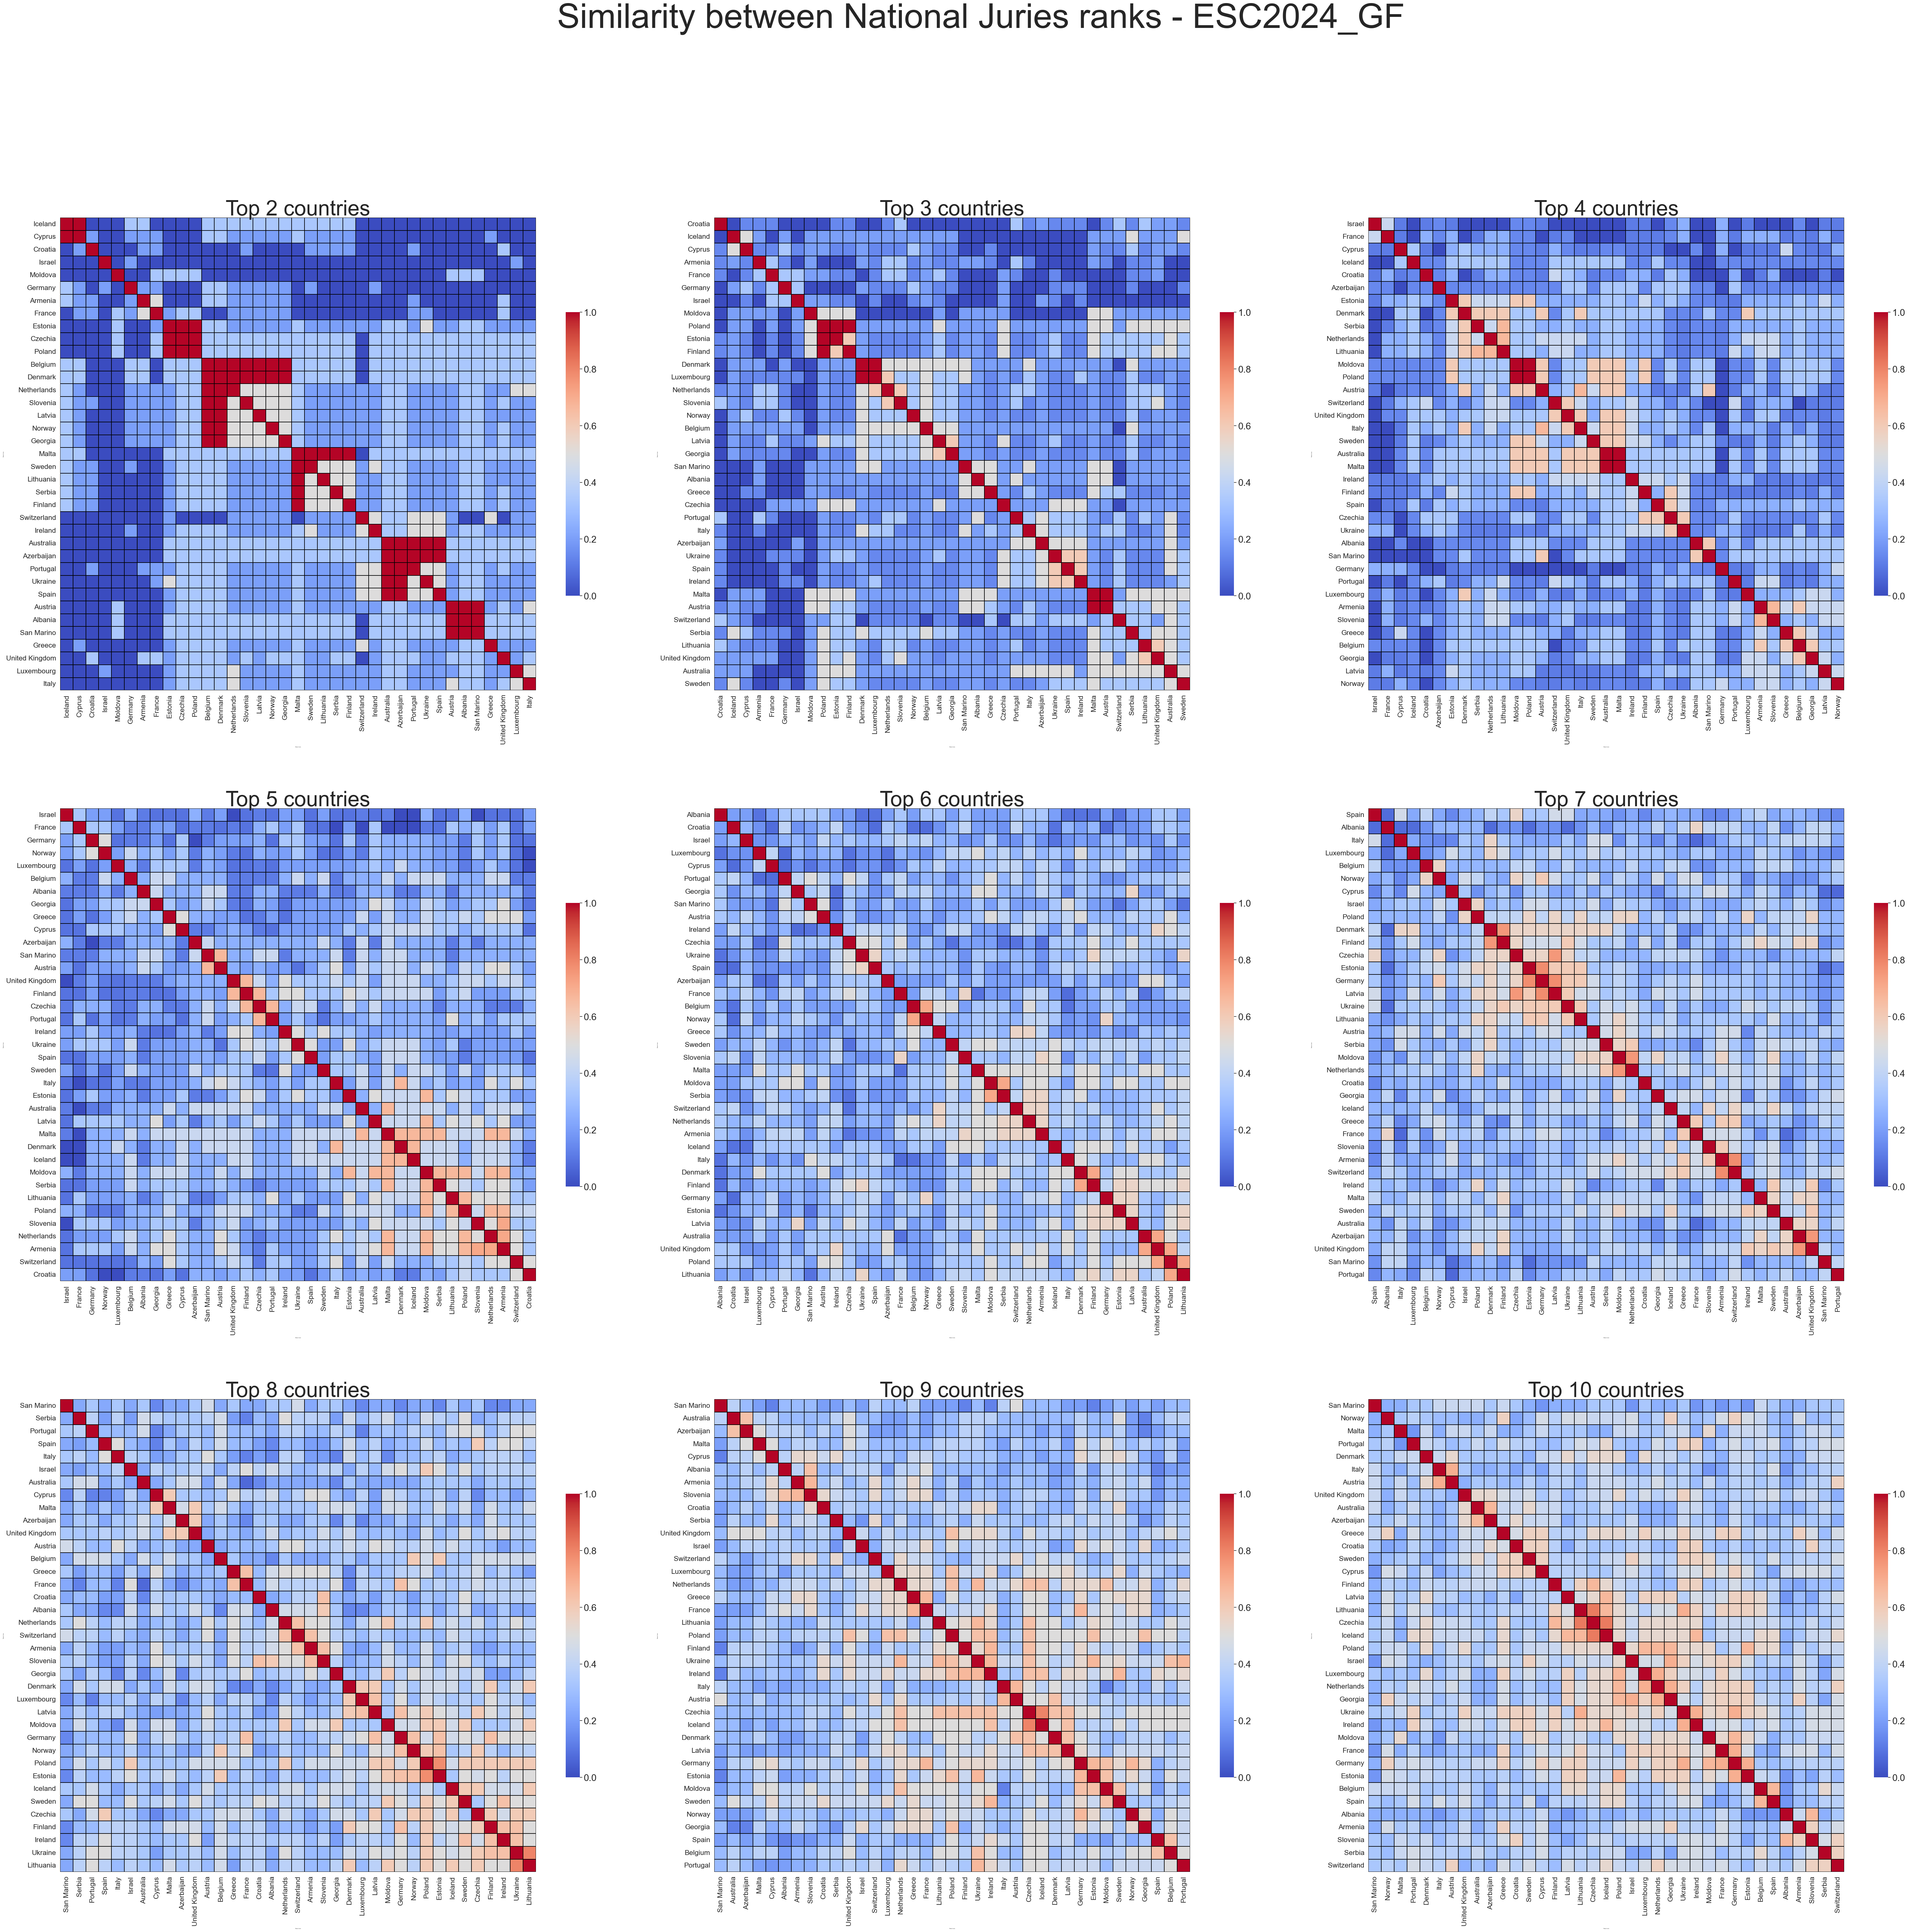

In [251]:
# Define the range of thresholds to consider, excluding threshold = 1
thresholds = range(2, 11)

# Set up the matplotlib figure and define dimensions for a 3x3 grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(80, 70))  # Adjusted figure size
fig.subplots_adjust(hspace=0.25, wspace=0.1)  # Adjusted spacing
axes = axes.flatten()

# Loop through threshold values from 2 to 10
for i, threshold in enumerate(thresholds):
    # Replace values above the threshold with 0
    #rank_table_0 = rank_table.where(rank_table <= threshold, 0)
    df_binary = gf_jurors_df.applymap(lambda x: 0 if (x > threshold) & (x !=0) else 1)
    correlation_matrix = calculate_jaccard(df_binary, option_own = "False")
    linked = linkage(correlation_matrix, 'single')
    order = leaves_list(linked)
    ordered_corr_matrix = correlation_matrix.iloc[order, order]

    # Plot the heatmap in each subplot
    ax = axes[i]
    sns.set(font_scale=2)
    sns.heatmap(ordered_corr_matrix, annot=False, cmap='coolwarm', fmt=".1f", 
                linewidths=.2, linecolor='black', vmin=0, vmax=1, cbar_kws={"shrink": .6}, ax=ax)
    sns.set(font_scale=2.5)
    ax.set_title(f'Top {threshold} countries', fontsize=50)
    ax.set_xlabel('National Juries', fontsize=2)
    ax.set_ylabel('National Juries', fontsize=2)

    
plt.gcf().set_facecolor('white')  # for the figure
plt.gca().set_facecolor('whitesmoke')  # for the axes
# Adjust the overall figure settings
plt.suptitle('Similarity between National Juries ranks - ESC2024_GF', fontsize=80)
#plt.show()
plt.savefig(os.path.join(output_folder,"ESC2024_GF_Juries_Similarity.jpg"), dpi=450, bbox_inches='tight')

<center>
    <h2>Plot Jaccard matrix for threshold = 5</h2>
</center>

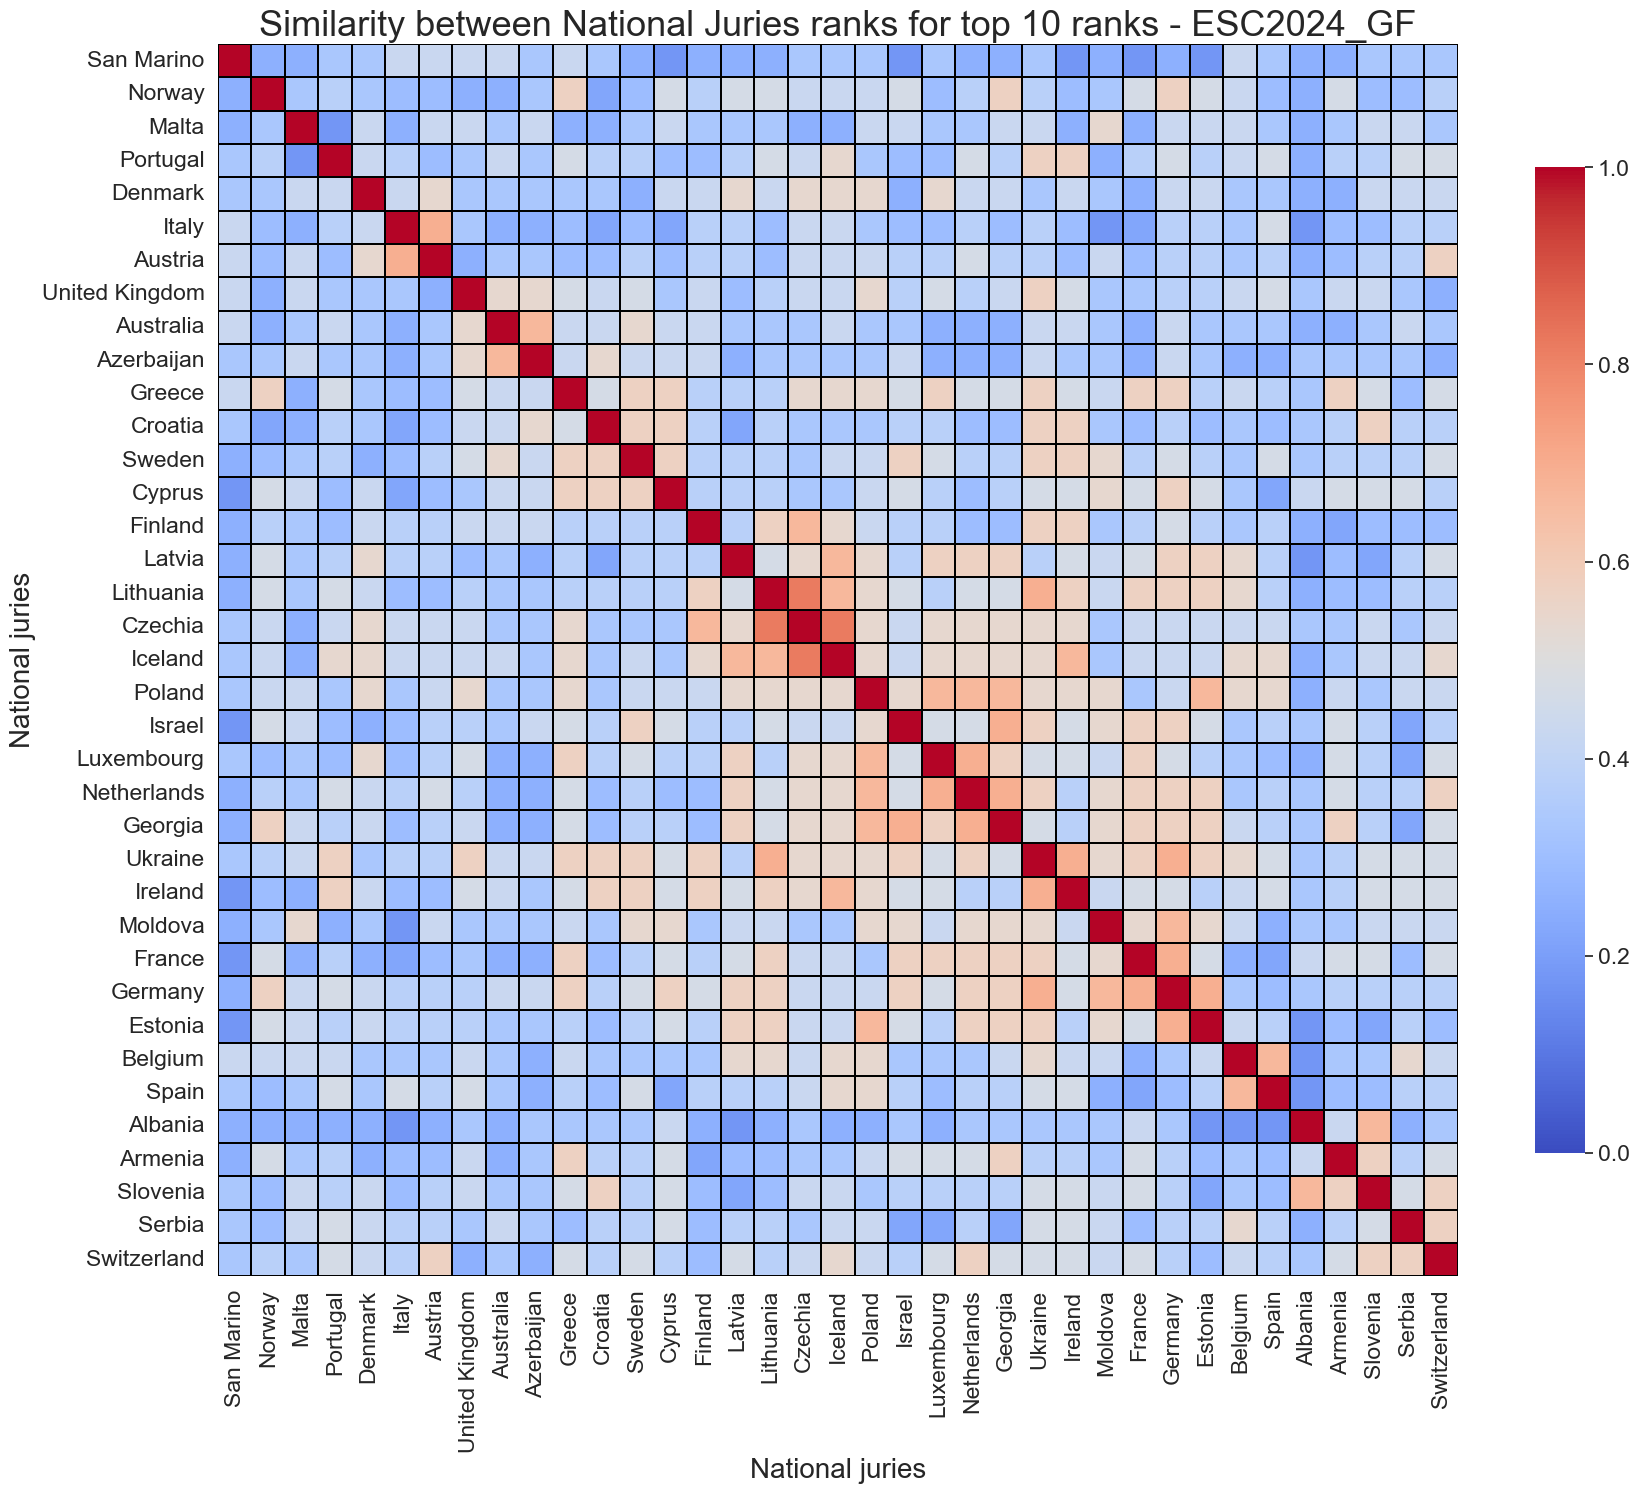

In [250]:
threshold = 10
df_binary = gf_jurors_df.applymap(lambda x: 0 if (x > threshold) & (x !=0) else 1)
correlation_matrix = calculate_jaccard(df_binary, option_own = "False")
linked = linkage(correlation_matrix, 'single')
order = leaves_list(linked)
ordered_corr_matrix = correlation_matrix.iloc[order, order]
# Customize the figure size
plt.figure(figsize=(20, 16))
#mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
mask = np.eye(len(correlation_matrix), dtype=bool)
# Plot the heatmap
sns.set(font_scale=1.5)
sns.heatmap(ordered_corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", 
            linewidths=.05, linecolor='black', vmin=0, vmax=1,cbar_kws={"shrink": .8})

# vmin=0, vmax=1,
# Rotate labels if necessary
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Set labels and title with custom font size
plt.xlabel('National juries', fontsize=20)
plt.ylabel('National juries', fontsize=20)
plt.title('Similarity between National Juries ranks for top 10 ranks - ESC2024_GF', fontsize=26)

# Set background color
plt.gcf().set_facecolor('white')  # for the figure
plt.gca().set_facecolor('whitesmoke')  # for the axes

#plt.show()
plt.savefig(os.path.join(output_folder, "ESC2024_GF_Juries_Similarity_Top10.jpg"), dpi=300, bbox_inches='tight')
#plt.savefig('heatmap_voting_analysis_top10.png', dpi=300, bbox_inches='tight')

<center>
    <h2>Table matching voted countries</h2>
</center>

In [242]:
df_Belgium_matching_top2= get_matching_countries(df_all = result_df, base_country = "Spain", nb_place_looked = 3, match_threshold = 2
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Belgium_matching_top2)

,Spain,Australia,Azerbaijan,Czechia,Ukraine,Ireland,Italy,Portugal
1st Place,Switzerland,Ireland,Switzerland,,Switzerland,Switzerland,Switzerland,Switzerland
2st Place,Ireland,Switzerland,Ireland,Switzerland,Ireland,Sweden,,Ireland
3st Place,Sweden,,,Sweden,Sweden,,Ireland,


In [112]:
df_Czechia_matching_top10 = get_matching_countries(df_all = result_df, base_country = "Czechia", nb_place_looked = 11, match_threshold = 7
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Czechia_matching_top10)

,Czechia,Ukraine
1st Place,Switzerland,Switzerland
2st Place,Sweden,Ireland
3st Place,Ireland,Sweden
4st Place,Armenia,Germany
5st Place,Germany,France
6st Place,France,
7st Place,Portugal,Croatia
8st Place,Croatia,Portugal


In [248]:
df_malta_matching_top4 = get_matching_countries(df_all = result_df, base_country = "Malta", nb_place_looked = 5, match_threshold = 4
                                            , fill_option = 'None',base_country_opt= "True")
display(df_malta_matching_top4)
#df_malta_matching_top9.to_excel(os.path.join(output_folder, "malta_matching_top9.xlsx"))

,Malta,Australia,Denmark,Iceland,Moldova,Netherlands,Serbia,Armenia
1st Place,Switzerland,Ireland,Switzerland,France,,Switzerland,Croatia,France
2st Place,Croatia,Switzerland,France,Croatia,Italy,France,Switzerland,
3st Place,Italy,Croatia,,,Croatia,,France,Italy
4st Place,Ireland,Italy,Croatia,Ireland,Switzerland,Croatia,,Switzerland
5st Place,France,,Ireland,Switzerland,France,Italy,Italy,Croatia


In [101]:
df_Australia_matching_top4 = get_matching_countries(df_all = result_df, base_country = "Australia", nb_place_looked = 5, match_threshold = 3 
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Australia_matching_top4)
#df_armenia_matching_top10.to_excel(os.path.join(output_folder, "armenia_matching_top10.xlsx"))

,Australia,Moldova,Poland,Sweden,Netherlands,Estonia,Ireland,Greece,United Kingdom,Serbia,Finland,Armenia,Austria
1st Place,Switzerland,Italy,,Switzerland,Switzerland,Switzerland,Switzerland,Switzerland,,Croatia,Switzerland,,Switzerland
2st Place,Croatia,Croatia,Croatia,Croatia,,,Sweden,Cyprus,Switzerland,Switzerland,Croatia,,Italy
3st Place,Italy,Switzerland,Italy,,,Croatia,,Italy,Croatia,,,Italy,Croatia
4st Place,Cyprus,,,Italy,Croatia,,Croatia,,,,Sweden,Switzerland,
5st Place,Sweden,,Sweden,,Italy,Sweden,,,Sweden,Italy,,Croatia,


In [91]:
df_Ukraine_matching_top8 = get_matching_countries(df_all = result_df, base_country = "Ukraine", nb_place_looked = 8, match_threshold = 7
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Ukraine_matching_top8)
#df_Ukraine_matching_top8.to_excel(os.path.join(output_folder, "Ukraine_matching_top8.xlsx"))

,Ukraine,Czechia,Lithuania,Finland
1st Place,Switzerland,Switzerland,Switzerland,Switzerland
2st Place,Ireland,Sweden,Croatia,Croatia
3st Place,Sweden,Ireland,Portugal,Ukraine
4st Place,Germany,,France,Sweden
5st Place,France,Germany,Ukraine,Ireland
6st Place,Lithuania,France,Sweden,France
7st Place,Croatia,Portugal,,
8st Place,Portugal,Croatia,Ireland,Germany


In [228]:
df_Germany_matching_top7 = get_matching_countries(df_all = result_df, base_country = "Germany", nb_place_looked = 6, match_threshold = 5
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Germany_matching_top7)
#df_georgia_matching_top6.to_excel(os.path.join(output_folder, "georgia_matching_top6.xlsx"))

,Germany,Estonia,Latvia,Norway
1st Place,Sweden,Switzerland,Switzerland,Switzerland
2st Place,France,,France,France
3st Place,Israel,Croatia,,Israel
4st Place,Armenia,France,Armenia,Armenia
5st Place,Croatia,Sweden,Croatia,Germany
6st Place,Switzerland,Israel,Sweden,


In [254]:
df_Iceland_matching_top9 = get_matching_countries(df_all = result_df, base_country = "Iceland", nb_place_looked = 10, match_threshold = 8
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Iceland_matching_top9)
#df_georgia_matching_top6.to_excel(os.path.join(output_folder, "georgia_matching_top6.xlsx"))

,Iceland,Czechia,Lithuania,Ireland,Latvia
1st Place,France,Ukraine,Switzerland,Switzerland,Switzerland
2st Place,Croatia,Switzerland,Croatia,Sweden,France
3st Place,UnitedKingdom,Sweden,Portugal,,Ukraine
4st Place,Ireland,Ireland,France,Croatia,Armenia
5st Place,Switzerland,Armenia,Ukraine,Germany,Croatia
6st Place,Armenia,Germany,Sweden,Portugal,Sweden
7st Place,Portugal,France,,UnitedKingdom,Germany
8st Place,Ukraine,Portugal,Ireland,France,
9st Place,Germany,Croatia,,Ukraine,UnitedKingdom
10st Place,Sweden,,Germany,,


In [42]:
df_UK_matching_top7 = get_matching_countries(df_all = result_df, base_country = "United Kingdom", nb_place_looked = 7, match_threshold = 5
                                            , fill_option = 'None',base_country_opt= "True")
display(df_UK_matching_top7)
#df_armenia_matching_top10.to_excel(os.path.join(output_folder, "armenia_matching_top10.xlsx"))

,United Kingdom,Azerbaijan,Sweden,Ireland,Finland
1st Place,Portugal,Ireland,Switzerland,Switzerland,Switzerland
2st Place,Switzerland,Luxembourg,Croatia,Sweden,Croatia
3st Place,Croatia,,,Luxembourg,
4st Place,Ireland,Italy,Italy,Croatia,Sweden
5st Place,Sweden,Sweden,Luxembourg,,Ireland
6st Place,Italy,Croatia,,Portugal,
7st Place,Luxembourg,,Portugal,,Luxembourg


In [104]:
df_Poland_matching_top4 = get_matching_countries(df_all = result_df, base_country = "Poland", nb_place_looked = 5, match_threshold = 3
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Poland_matching_top4)

,Poland,Australia,Netherlands,Lithuania,Estonia,United Kingdom,Finland,Armenia,Switzerland,Croatia
1st Place,Ukraine,,,,,Portugal,,,,Portugal
2st Place,Croatia,Croatia,,Croatia,Ukraine,,Croatia,Portugal,,
3st Place,Italy,Italy,Portugal,Portugal,Croatia,Croatia,Ukraine,Italy,Croatia,
4st Place,Portugal,,Croatia,,,,Sweden,,Portugal,Ukraine
5st Place,Sweden,Sweden,Italy,Ukraine,Sweden,Sweden,,Croatia,Italy,Italy


In [224]:
df_Latvia_matching_top6 = get_matching_countries(df_all = result_df, base_country = "Latvia", nb_place_looked = 6, match_threshold = 5
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Latvia_matching_top6)

,Latvia,Germany,Lithuania,Estonia,Finland,Georgia
1st Place,Switzerland,Sweden,Switzerland,Switzerland,Switzerland,Switzerland
2st Place,France,France,Croatia,Ukraine,Croatia,France
3st Place,Ukraine,,,Croatia,Ukraine,Latvia
4st Place,Armenia,Armenia,France,France,Sweden,
5st Place,Croatia,Croatia,Ukraine,Sweden,,Armenia
6st Place,Sweden,Switzerland,Sweden,,France,Ukraine


In [188]:
df_Georgia_matching_top10 = get_matching_countries(df_all = result_df, base_country = "Georgia", nb_place_looked = 10, match_threshold = 8
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Georgia_matching_top10)

,Georgia,Poland,Luxembourg,Netherlands,Israel,Estonia,Norway
1st Place,Switzerland,Switzerland,Switzerland,Switzerland,,Switzerland,Switzerland
2st Place,France,Ukraine,,France,Germany,Ukraine,France
3st Place,Latvia,Croatia,France,Portugal,Ukraine,Croatia,Israel
4st Place,Italy,Italy,Latvia,Croatia,,France,Armenia
5st Place,Armenia,Portugal,,Italy,Italy,,Germany
6st Place,Ukraine,,Croatia,Germany,Switzerland,Israel,Italy
7st Place,Portugal,Germany,Ukraine,,Croatia,Germany,Ukraine
8st Place,Israel,France,Germany,Armenia,Portugal,Italy,
9st Place,Germany,Latvia,Portugal,Ukraine,Georgia,,
10st Place,Croatia,,Armenia,Latvia,France,Latvia,Georgia


In [191]:
df_Armenia_matching_top5 = get_matching_countries(df_all = result_df, base_country = "Armenia", nb_place_looked = 5, match_threshold = 5
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Armenia_matching_top5)

,Armenia,Netherlands,Slovenia
1st Place,France,Switzerland,France
2st Place,Portugal,France,Switzerland
3st Place,Italy,Portugal,Portugal
4st Place,Switzerland,Croatia,Armenia
5st Place,Croatia,Italy,Croatia


In [220]:
df_Moldova_matching_top5 = get_matching_countries(df_all = result_df, base_country = "Moldova", nb_place_looked = 5, match_threshold = 4
                                            , fill_option = 'None',base_country_opt= "True")
display(df_Moldova_matching_top5)

,Moldova,Malta,Poland,Netherlands,Lithuania,Estonia,Latvia,Serbia,Armenia
1st Place,Ukraine,Switzerland,Switzerland,Switzerland,Switzerland,Switzerland,Switzerland,Croatia,France
2st Place,Italy,Croatia,Ukraine,France,Croatia,Ukraine,France,Switzerland,
3st Place,Croatia,Italy,Croatia,,,Croatia,Ukraine,France,Italy
4st Place,Switzerland,,Italy,Croatia,France,France,,,Switzerland
5st Place,France,France,,Italy,Ukraine,,Croatia,Italy,Croatia
